# 01 — EDA & Preprocessing
**Analisis Pengelompokan Tingkat Stabilitas Harga Pangan Nasional Menggunakan K-Means Clustering Berdasarkan Indeks Koefisien Variasi**

Fadhlilah Musa Ulil Albab — A11.2024.15975 — Teknik Informatika, UDINUS

Notebook ini memuat: pemuatan & pembersihan 3 dataset, analisis kualitas data, 5 insight EDA tervisualisasi, dan pembentukan dataset terintegrasi untuk clustering.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)

## 1. Load Data Mentah
Tiga dataset (sumber: Badan Pangan Nasional / panelharga.badanpangan.go.id):
1. **Koefisien Variasi (KV) harga produsen 2022–2024** — separator `;`, 3 baris judul dilewati, nilai string `"7,09%"`.
2. **Cadangan Pangan Pemerintah Daerah (CPPD) 2025** — separator `;`, desimal koma.
3. **Sertifikat JKP nasional 2018–2024** — ada typo tahun `202` yang dikoreksi menjadi `2020`.

In [2]:
from data_preprocessing import load_kv, load_cppd, load_sertifikat

kv = load_kv()
cppd = load_cppd()
sert = load_sertifikat()
print("KV     :", kv.shape)
print("CPPD   :", cppd.shape)
print("Sert.  :", sert.shape)
kv.head()

KV     : (11232, 7)
CPPD   : (418, 5)
Sert.  : (7, 2)


,Kode Wilayah,Provinsi,Komoditas,Tahun,Bulan,Koefisien Variasi,KV
0,11,Aceh,GKP Tingkat Petani,2022,Januari,"7,09%",7.09
1,51,Bali,GKP Tingkat Petani,2022,Januari,"7,15%",7.15
2,36,Banten,GKP Tingkat Petani,2022,Januari,"3,88%",3.88
3,17,Bengkulu,GKP Tingkat Petani,2022,Januari,NaN,NaN
4,34,DI Yogyakarta,GKP Tingkat Petani,2022,Januari,"3,20%",3.20


In [3]:
cppd.head()

,Tahun,Bulan,Kode_Wilayah,Provinsi,CPPD_Ton
0,2025,31 Januari 2025,11,Aceh,191.10
1,2025,31 Januari 2025,12,Sumatera Utara,57.27
2,2025,31 Januari 2025,13,Sumatera Barat,119.34
3,2025,31 Januari 2025,14,Riau,85.10
4,2025,31 Januari 2025,15,Jambi,66.14


In [4]:
sert

,Jumlah_Sertifikat,Tahun
0,0,2018
1,0,2019
2,0,2020
3,43,2021
4,551,2022
5,659,2023
6,611,2024


## 2. Analisis Kualitas Data
Diperiksa: missing values, duplikat, inkonsistensi penamaan, dan outlier.

In [5]:
print("=== Missing values KV ===")
print(f"KV missing: {kv['KV'].isna().sum()} dari {len(kv)} baris ({kv['KV'].isna().mean():.1%})")
print("\n=== Duplikat ===")
print(f"Duplikat KV: {kv.duplicated().sum()}, CPPD: {cppd.duplicated().sum()}")
print("\n=== Cakupan provinsi ===")
print(f"KV: {kv['Provinsi'].nunique()} provinsi | CPPD: {cppd['Provinsi'].nunique()} provinsi")
print("\n=== Inkonsistensi yang sudah dinormalisasi ===")
print("- 'D.I Yogyakarta' (KV) vs 'DI Yogyakarta' (CPPD) -> disamakan")
print("- 'Jagung Pipilan Kering TK. Petani' vs 'Tk. Petani' -> disamakan")
print("- Typo tahun sertifikat '202' -> 2020")
print(f"\nJumlah komoditas setelah normalisasi: {kv['Komoditas'].nunique()}")

=== Missing values KV ===
KV missing: 4541 dari 11232 baris (40.4%)

=== Duplikat ===
Duplikat KV: 0, CPPD: 0

=== Cakupan provinsi ===
KV: 26 provinsi | CPPD: 38 provinsi

=== Inkonsistensi yang sudah dinormalisasi ===
- 'D.I Yogyakarta' (KV) vs 'DI Yogyakarta' (CPPD) -> disamakan
- 'Jagung Pipilan Kering TK. Petani' vs 'Tk. Petani' -> disamakan
- Typo tahun sertifikat '202' -> 2020

Jumlah komoditas setelah normalisasi: 14


In [6]:
# Outlier CPPD: Jawa Barat ekstrem (~2.152 ton, jauh di atas provinsi lain)
cppd_prov = cppd.groupby("Provinsi")["CPPD_Ton"].mean().sort_values(ascending=False)
print(cppd_prov.head(8).round(2))
print("\nCatatan: CPPD Jawa Barat adalah outlier faktual (bukan error), begitu juga provinsi dengan CPPD 0.00 — keduanya dipertahankan.")

Provinsi
Jawa Barat            2152.09
Kalimantan Timur       481.39
Jawa Timur             449.43
Banten                 443.52
Bali                   390.38
Kalimantan Selatan     361.79
Sulawesi Tengah        315.39
DI Yogyakarta          305.30
Name: CPPD_Ton, dtype: float64

Catatan: CPPD Jawa Barat adalah outlier faktual (bukan error), begitu juga provinsi dengan CPPD 0.00 — keduanya dipertahankan.


## 3. Insight 1 — Distribusi KV per Tahun
Boxplot KV lintas provinsi-komoditas per tahun. Ekspektasi: 2022 tinggi (~9%), 2023 turun tajam, 2024 naik kembali moderat.

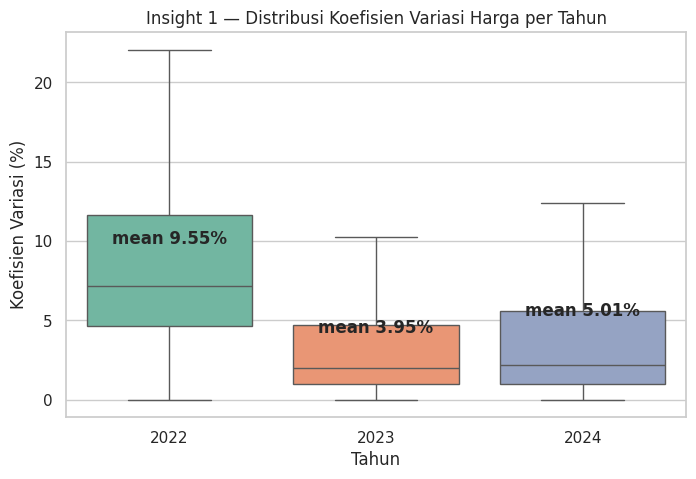

Tahun
2022    9.55
2023    3.95
2024    5.01
Name: KV, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=kv, x="Tahun", y="KV", hue="Tahun", palette="Set2", showfliers=False, legend=False, ax=ax)
means = kv.groupby("Tahun")["KV"].mean()
for i, (t, m) in enumerate(means.items()):
    ax.annotate(f"mean {m:.2f}%", (i, m), ha="center", va="bottom", fontweight="bold")
ax.set_title("Insight 1 — Distribusi Koefisien Variasi Harga per Tahun")
ax.set_ylabel("Koefisien Variasi (%)")
fig.savefig(FIG / "eda1_boxplot_kv_tahun.png", dpi=150, bbox_inches="tight")
plt.show()
print(means.round(2))

**Interpretasi:** volatilitas harga produsen tertinggi pada 2022 (efek disrupsi rantai pasok global), membaik drastis pada 2023, lalu naik kembali pada 2024 (fenomena El Niño). Stabilitas harga bersifat dinamis antar tahun sehingga ketiga tahun dipakai sebagai fitur terpisah.

## 4. Bangun Dataset Terintegrasi
Mean KV per (Provinsi, Tahun) → pivot `KV_2022..KV_2024`; mean CPPD 2025 per provinsi; merge inner; imputasi median; fitur EDA `KV_mean` & `KV_trend`.

In [8]:
from data_preprocessing import build_integrated_dataset
df = build_integrated_dataset(save=True)
print(f"{df.shape[0]} provinsi (KV hanya mencakup 26 provinsi; 1 drop karena KV kosong semua -> normal)")
df

Tersimpan: /sessions/intelligent-loving-curie/mnt/DATASET-PM/capstone-project-data-mining/data/processed/dataset_pangan_terintegrasi.csv (25 provinsi x 7 kolom)
25 provinsi (KV hanya mencakup 26 provinsi; 1 drop karena KV kosong semua -> normal)


,Provinsi,KV_2022,KV_2023,KV_2024,CPPD_Ton,KV_mean,KV_trend
0,Aceh,9.321818,3.147200,3.400959,187.463636,5.289992,-5.920859
1,Bali,8.461557,4.268108,4.691667,390.380000,5.807111,-3.769891
2,Banten,6.678073,3.720219,6.268542,443.520000,5.555611,-0.409532
3,Bengkulu,13.274615,5.543200,10.182917,63.104545,9.666911,-3.091699
4,DI Yogyakarta,10.107024,5.646569,6.856341,305.300000,7.536645,-3.250682
5,Gorontalo,7.023846,9.669394,9.173500,8.154545,8.622247,2.149654
6,Jambi,10.768268,2.771176,2.842137,66.140000,5.460527,-7.926130
7,Jawa Barat,9.147153,4.167569,4.510556,2152.091818,5.941759,-4.636597
8,Jawa Tengah,11.186806,3.944514,4.791111,102.583636,6.640810,-6.395694
9,Jawa Timur,12.864514,4.766528,5.485764,449.430000,7.705602,-7.378750


## 5. Insight 2 — Ranking Provinsi Berdasarkan KV Rata-rata

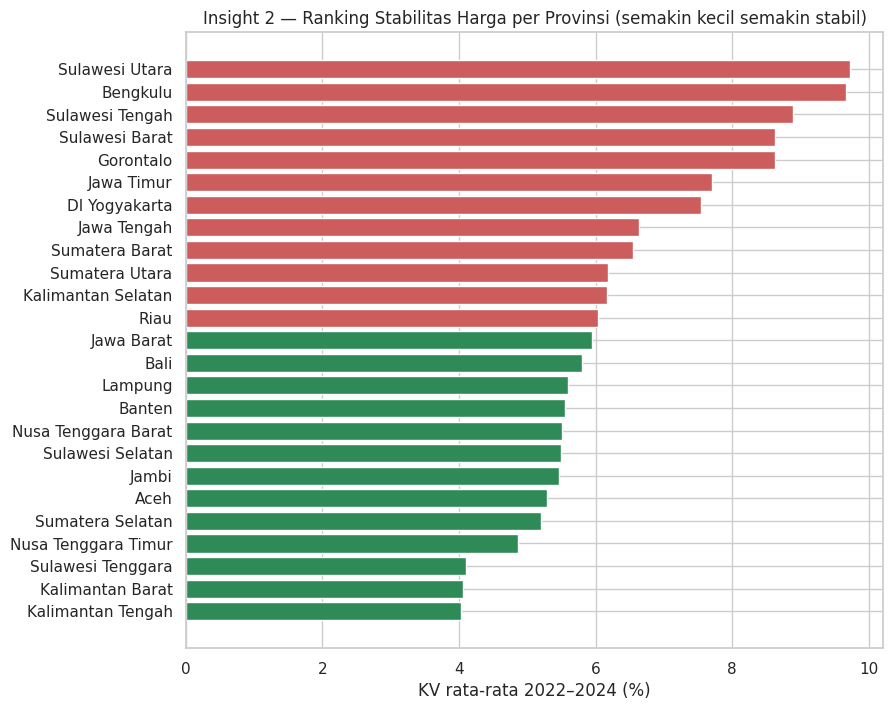

Paling stabil : Kalimantan Tengah (4.03%)
Paling fluktuatif: Sulawesi Utara (9.73%)


In [9]:
d = df.sort_values("KV_mean")
fig, ax = plt.subplots(figsize=(9, 8))
colors = ["indianred" if v > d["KV_mean"].median() else "seagreen" for v in d["KV_mean"]]
ax.barh(d["Provinsi"], d["KV_mean"], color=colors)
ax.set_xlabel("KV rata-rata 2022–2024 (%)")
ax.set_title("Insight 2 — Ranking Stabilitas Harga per Provinsi (semakin kecil semakin stabil)")
fig.savefig(FIG / "eda2_ranking_provinsi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Paling stabil :", d["Provinsi"].iloc[0], f'({d["KV_mean"].iloc[0]:.2f}%)')
print("Paling fluktuatif:", d["Provinsi"].iloc[-1], f'({d["KV_mean"].iloc[-1]:.2f}%)')

## 6. Insight 3 — Korelasi Antar Fitur

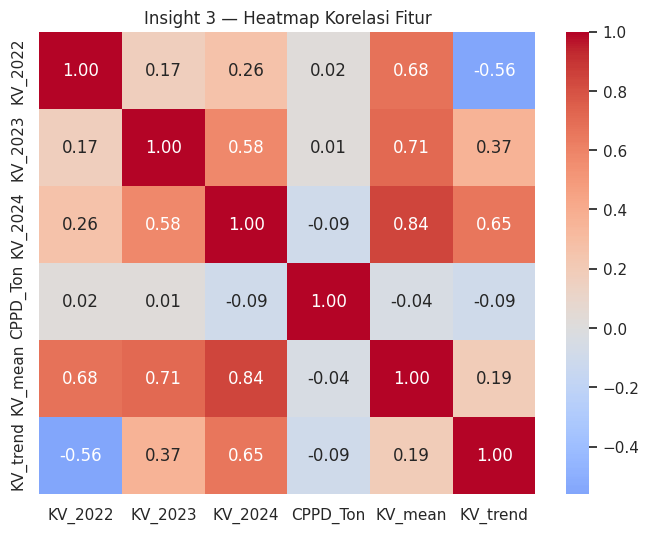

In [10]:
num_cols = ["KV_2022", "KV_2023", "KV_2024", "CPPD_Ton", "KV_mean", "KV_trend"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Insight 3 — Heatmap Korelasi Fitur")
fig.savefig(FIG / "eda3_heatmap_korelasi.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretasi:** KV antar tahun berkorelasi positif moderat (provinsi fluktuatif cenderung tetap fluktuatif), sedangkan CPPD hampir tidak berkorelasi dengan KV — diuji formal pada insight berikutnya.

## 7. Insight 4 — Uji Hipotesis Proposal: CPPD tinggi ↔ KV rendah?

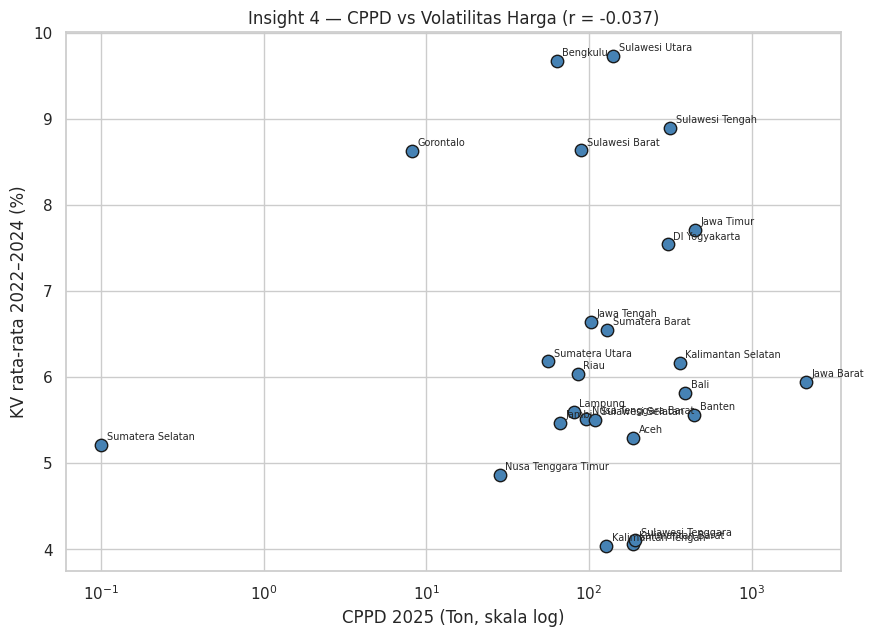

Korelasi Pearson CPPD vs KV_mean: r = -0.0374


In [11]:
r = df["CPPD_Ton"].corr(df["KV_mean"])
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df["CPPD_Ton"].clip(lower=0.1), df["KV_mean"], s=80, color="steelblue", edgecolor="k")
for _, row in df.iterrows():
    ax.annotate(row["Provinsi"], (max(row["CPPD_Ton"], 0.1), row["KV_mean"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("CPPD 2025 (Ton, skala log)")
ax.set_ylabel("KV rata-rata 2022–2024 (%)")
ax.set_title(f"Insight 4 — CPPD vs Volatilitas Harga (r = {r:.3f})")
fig.savefig(FIG / "eda4_scatter_cppd_kv.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Korelasi Pearson CPPD vs KV_mean: r = {r:.4f}")

**Temuan penting (dibahas jujur di laporan):** hipotesis proposal bahwa cadangan pangan besar berasosiasi dengan harga lebih stabil **TIDAK terbukti** (r ≈ −0.04, praktis nol). Implikasi: besaran stok CPPD saja tidak menjamin stabilitas harga — faktor distribusi/logistik dan struktur pasar lokal kemungkinan lebih dominan. Justru karena independen, CPPD tetap informatif sebagai dimensi terpisah dalam clustering.

## 8. Insight 5 — Konteks Nasional: Sertifikat JKP & Komoditas Paling Fluktuatif
Data sertifikat JKP hanya tersedia level **nasional** sehingga tidak bisa menjadi fitur clustering per provinsi (deviasi dari proposal → limitasi data). Ditampilkan sebagai konteks.

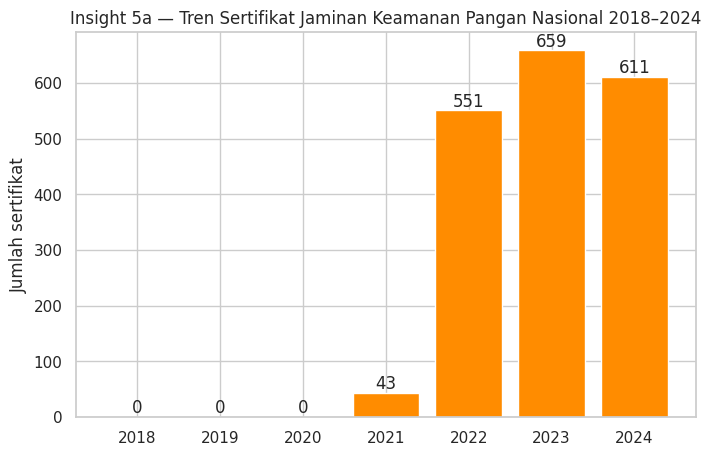

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sert["Tahun"].astype(str), sert["Jumlah_Sertifikat"], color="darkorange")
for x, y in zip(sert["Tahun"].astype(str), sert["Jumlah_Sertifikat"]):
    ax.annotate(str(int(y)), (x, y), ha="center", va="bottom")
ax.set_title("Insight 5a — Tren Sertifikat Jaminan Keamanan Pangan Nasional 2018–2024")
ax.set_ylabel("Jumlah sertifikat")
fig.savefig(FIG / "eda5a_sertifikat_jkp.png", dpi=150, bbox_inches="tight")
plt.show()

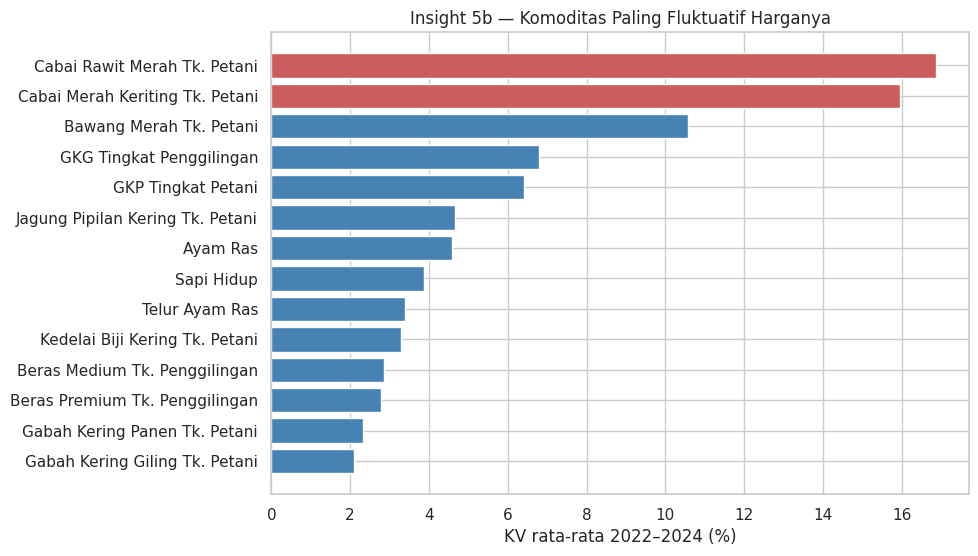

Paling fluktuatif: Cabai Rawit Merah Tk. Petani, Cabai Merah Keriting Tk. Petani


In [13]:
kom = kv.groupby("Komoditas")["KV"].mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(kom.index, kom.values, color=["indianred" if v >= kom.values[-2] else "steelblue" for v in kom.values])
ax.set_xlabel("KV rata-rata 2022–2024 (%)")
ax.set_title("Insight 5b — Komoditas Paling Fluktuatif Harganya")
fig.savefig(FIG / "eda5b_komoditas_fluktuatif.png", dpi=150, bbox_inches="tight")
plt.show()
print("Paling fluktuatif:", ", ".join(kom.index[-2:][::-1]))

**Interpretasi:** cabai dan bawang merah adalah komoditas paling fluktuatif — konsisten dengan karakter hortikultura (mudah busuk, panen musiman, rantai pasok panjang). Kebijakan stabilisasi per segmen provinsi perlu memprioritaskan komoditas ini.

## 9. Ringkasan Preprocessing
1. Parsing khusus per file (separator `;`, skiprows, desimal koma, `%`).
2. Cleansing: KV string→float, typo tahun `202`→2020, normalisasi nama provinsi & komoditas.
3. Agregasi mean KV per (Provinsi, Tahun) → pivot 3 kolom tahun; mean CPPD 2025.
4. Merge inner on Provinsi → **25 provinsi**; imputasi median per kolom KV.
5. Fitur clustering: `[KV_2022, KV_2023, KV_2024, CPPD_Ton]` + StandardScaler (dilakukan di notebook 02).
6. **Tidak ada train/test split** — clustering bersifat unsupervised dan bertujuan memetakan seluruh populasi provinsi, bukan memprediksi data baru; evaluasi memakai metrik internal (Silhouette, DBI).